# 03 - Estimacion de riesgo: PD, LGD y costo de fondeo (Fase 7)

Ambos modelos se entrenan solo sobre `accepted` (no tiene sentido estimar riesgo de un préstamo que nunca se otorgó) y a nivel de **cliente individual** -- la agregación a sub_grade se hace en `04_aggregation_subgrade.ipynb` (Fase 4/6), promediando estas predicciones individuales, no reentrenando un modelo agregado.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, mean_absolute_error, roc_auc_score
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.risk_model import (  # noqa: E402
    FUNDING_COST_BASE,
    FUNDING_COST_SENSITIVITY,
    LGD_INDUSTRY_BENCHMARK,
    RISK_FEATURES,
    compute_lgd_target,
    filter_resolved_loans,
    lgd_model_pipeline,
    pd_model_pipeline,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (9, 4)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

accepted_clean = pd.read_csv(PROCESSED_DIR / "accepted_clean.csv.gz", low_memory=False)
print(f"accepted_clean: {accepted_clean.shape}")

accepted_clean: (149996, 155)


## 1. PD -- probabilidad de default

**Decisión de filtrado de datos, la más importante de esta sección:** solo se entrena con préstamos que tienen un **desenlace final resuelto** -- `Fully Paid` (no default) o `Charged Off`/`Default` (default). Se excluyen `Current`, `Late (16-30/31-120 days)` e `In Grace Period`: son préstamos **censurados**, todavía en curso, cuyo desenlace final se desconoce. Etiquetarlos como "no default" porque hoy están al día sería un sesgo optimista sistemático -- muchos de esos préstamos "Current" eventualmente caerán en default, y el modelo nunca vería esos casos.

In [2]:
resolved = filter_resolved_loans(accepted_clean)
print(f"Préstamos resueltos: {len(resolved):,} de {len(accepted_clean):,} totales")
print()
print(resolved["loan_status"].value_counts())
print()
print(f"Tasa de default (base rate): {resolved['default'].mean():.4f}")

Préstamos resueltos: 89,347 de 149,996 totales

loan_status
Fully Paid                                             71242
Charged Off                                            17950
Does not meet the credit policy. Status:Fully Paid       105
Does not meet the credit policy. Status:Charged Off       48
Default                                                    2
Name: count, dtype: int64

Tasa de default (base rate): 0.2015


In [3]:
X = resolved[RISK_FEATURES]
y = resolved["default"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pd_pipeline = pd_model_pipeline()
pd_pipeline.fit(X_train, y_train)
pd_proba_test = pd_pipeline.predict_proba(X_test)[:, 1]

auc_pd = roc_auc_score(y_test, pd_proba_test)
brier_pd = brier_score_loss(y_test, pd_proba_test)
print(f"PD model -- AUC: {auc_pd:.4f} | Brier: {brier_pd:.4f}")

PD model -- AUC: 0.6968 | Brier: 0.1472


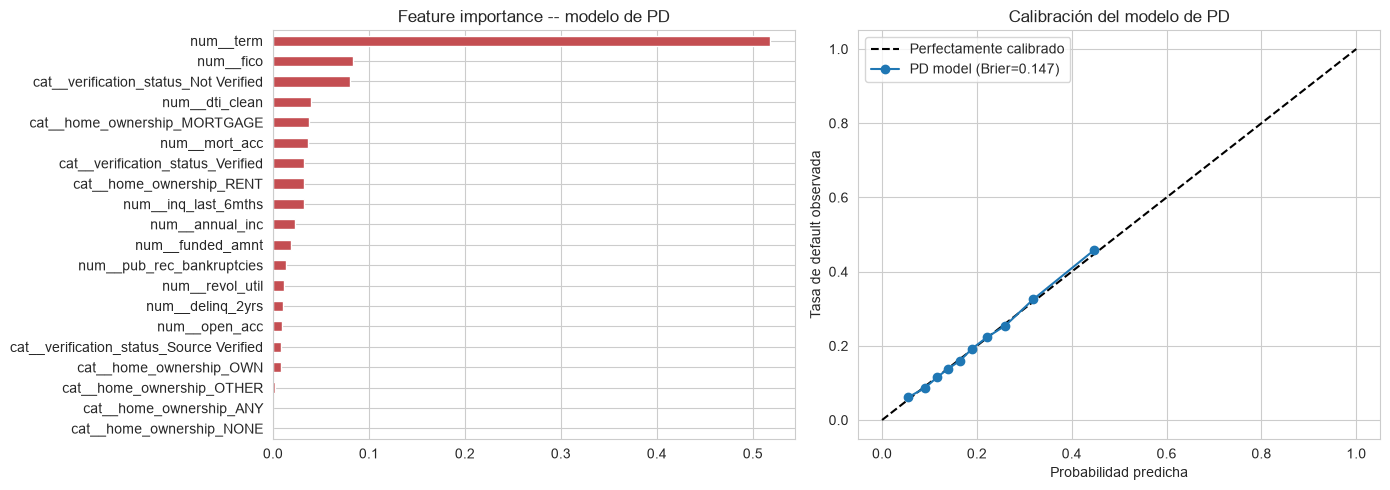

In [4]:
feature_names_pd = pd_pipeline.named_steps["preprocess"].get_feature_names_out()
importances_pd = pd.Series(
    pd_pipeline.named_steps["model"].feature_importances_, index=feature_names_pd
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

importances_pd.plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].set_title("Feature importance -- modelo de PD")

frac_pos, mean_pred = calibration_curve(y_test, pd_proba_test, n_bins=10, strategy="quantile")
axes[1].plot([0, 1], [0, 1], "k--", label="Perfectamente calibrado")
axes[1].plot(mean_pred, frac_pos, marker="o", label=f"PD model (Brier={brier_pd:.3f})")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Tasa de default observada")
axes[1].set_title("Calibración del modelo de PD")
axes[1].legend()

plt.tight_layout()
plt.show()

**Lectura de negocio:** un AUC ~0.70 es consistente con lo reportado en la literatura pública sobre modelos de PD entrenados con este mismo dataset de LendingClub -- el riesgo de default de crédito personal no garantizado es intrínsecamente difícil de predecir con la información disponible al momento de originar el préstamo (a diferencia de fraude o mora temprana, que suelen tener señales más fuertes). La calibración es razonable (cerca de la diagonal), lo cual importa tanto como el AUC porque la Fase 8 usa `PD_i` directamente en la resta de pérdida esperada de la fórmula de Phillips.

Se reentrena el modelo con **todos** los préstamos resueltos (sin separar train/test) para el modelo de producción, y se aplica a **todos** los clientes de `accepted` -- incluidos los que todavía están "Current" -- porque la Fase 4 necesita un `PD` individual para cada cliente real del dataset al momento de agregar por sub_grade, no solo para los que ya tienen desenlace.

In [5]:
pd_pipeline_final = pd_model_pipeline()
pd_pipeline_final.fit(resolved[RISK_FEATURES], resolved["default"])

accepted_clean["pd_individual"] = pd_pipeline_final.predict_proba(
    accepted_clean[RISK_FEATURES]
)[:, 1]

joblib.dump(pd_pipeline_final, MODELS_DIR / "pd_model.joblib")
print(f"PD individual -- media: {accepted_clean['pd_individual'].mean():.4f}")
accepted_clean[["loan_status", "pd_individual"]].groupby("loan_status").mean()

PD individual -- media: 0.2052


C:\Users\josue\AppData\Local\Temp\ipykernel_44684\2200859694.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  accepted_clean["pd_individual"] = pd_pipeline_final.predict_proba(


,pd_individual
loan_status,
Charged Off,0.274568
Current,0.209034
Default,0.265636
Does not meet the credit policy. Status:Charged Off,0.339231
Does not meet the credit policy. Status:Fully Paid,0.209980
Fully Paid,0.182938
In Grace Period,0.259071
Late (16-30 days),0.258574
Late (31-120 days),0.253399


## 2. LGD -- pérdida dado el default

A nivel individual, un cliente que nunca cayó en default no tiene un LGD histórico propio -- por eso no se puede simplemente promediar como a nivel de segmento amplio. Se entrena una **regresión** sobre los préstamos `Charged Off` (donde sí se observa un LGD realizado) y se aplica a todos los clientes.

`LGD = 1 - (recoveries - collection_recovery_fee) / EAD`

**Hallazgo empírico importante:** `out_prncp` (la variable que el enunciado del proyecto sugiere como primera opción para aproximar el EAD) resultó **inservible**: LendingClub lo pone en 0 para el 100% de los préstamos ya dados de baja en esta muestra (se verificó directamente). En su lugar se usa `funded_amnt - total_rec_prncp` (monto original menos lo que el cliente alcanzó a pagar de principal antes del default), la alternativa que el propio enunciado contempla.

Préstamos Charged Off con LGD calculable: 17,947


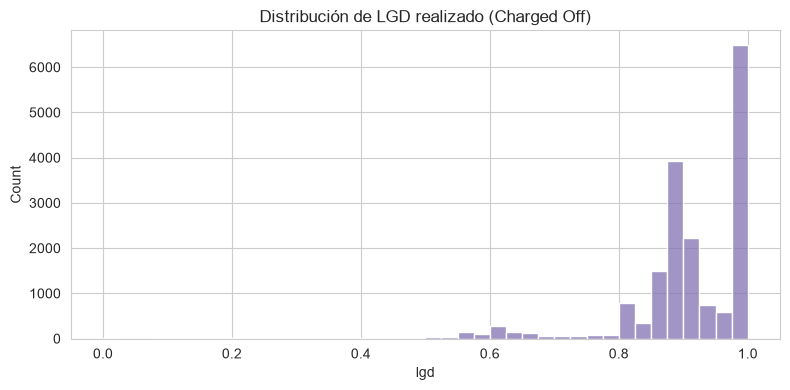

count    17947.000000
mean         0.907944
std          0.111040
min          0.000000
25%          0.880179
50%          0.915213
75%          1.000000
max          1.000000
Name: lgd, dtype: float64

Benchmark de industria (Basel/referencia): 45%


In [6]:
charged_off = compute_lgd_target(accepted_clean)
print(f"Préstamos Charged Off con LGD calculable: {len(charged_off):,}")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(charged_off["lgd"], bins=40, ax=ax, color="#8172B2")
ax.set_title("Distribución de LGD realizado (Charged Off)")
plt.tight_layout()
plt.show()

print(charged_off["lgd"].describe())
print(f"\nBenchmark de industria (Basel/referencia): {LGD_INDUSTRY_BENCHMARK:.0%}")

**Lectura de negocio:** el LGD realizado promedio (~91%) es sustancialmente más alto que el benchmark supervisorio de Basel (45%) que se usa como referencia genérica. Tiene sentido en este caso concreto: son préstamos personales **sin garantía** (unsecured), donde la única vía de recuperación de LendingClub es cobranza/judicial sobre un deudor que ya dejó de pagar -- las recuperaciones reales (`recoveries`) son en general una fracción pequeña del saldo pendiente. El benchmark de Basel de 45% es una referencia regulatoria genérica pensada para carteras retail más amplias (incluye crédito con garantía); para este producto específico, el dato empírico observado es más confiable que el benchmark genérico, y se usa como referencia principal en la Fase 4/6. El benchmark solo se usa como respaldo cuando un sub_grade no tiene muestra suficiente de Charged Off para confiar en el LGD modelado.

In [7]:
Xl = charged_off[RISK_FEATURES]
yl = charged_off["lgd"]
Xl_train, Xl_test, yl_train, yl_test = train_test_split(Xl, yl, test_size=0.2, random_state=42)

lgd_pipeline = lgd_model_pipeline()
lgd_pipeline.fit(Xl_train, yl_train)
lgd_pred_test = lgd_pipeline.predict(Xl_test)

mae_lgd = mean_absolute_error(yl_test, lgd_pred_test)
print(f"LGD model -- MAE: {mae_lgd:.4f} (media real: {yl_test.mean():.4f})")

LGD model -- MAE: 0.0737 (media real: 0.9097)


In [8]:
# Modelo de producción: reentrenado con todo el set de Charged Off,
# aplicado a TODOS los clientes de accepted (Fase 7 lo pide explícitamente)
lgd_pipeline_final = lgd_model_pipeline()
lgd_pipeline_final.fit(Xl, yl)

accepted_clean["lgd_individual"] = lgd_pipeline_final.predict(accepted_clean[RISK_FEATURES]).clip(
    0, 1
)

joblib.dump(lgd_pipeline_final, MODELS_DIR / "lgd_model.joblib")
print(f"LGD individual (todos los clientes) -- media: {accepted_clean['lgd_individual'].mean():.4f}")

LGD individual (todos los clientes) -- media: 0.9078


C:\Users\josue\AppData\Local\Temp\ipykernel_44684\2365563080.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  accepted_clean["lgd_individual"] = lgd_pipeline_final.predict(accepted_clean[RISK_FEATURES]).clip(


## 3. Costo de fondeo (`r_c`)

LendingClub es una plataforma P2P, no un banco tradicional -- no reporta un costo de fondeo propio (los fondos vienen de inversionistas individuales/institucionales, no de depósitos con un costo explícito). Esta es una **brecha metodológica real** del dataset, no una decisión de modelado.

**Caso base:** se asume `r_c = 3.5%`, dentro del rango de costo de fondeo retail bancario de referencia (Federal Reserve Bank of Minneapolis, "How do lenders set interest rates on loans"). **Análisis de sensibilidad** (usado en la Fase 8): se corre el optimizador también con `r_c ∈ {2%, 4%, 6%}` para mostrar cómo cambian las tasas óptimas recomendadas ante distintos supuestos de costo de fondeo.

In [9]:
print(f"Costo de fondeo (caso base): {FUNDING_COST_BASE:.1%}")
print(f"Escenarios de sensibilidad: {[f'{r:.1%}' for r in FUNDING_COST_SENSITIVITY]}")

Costo de fondeo (caso base): 3.5%
Escenarios de sensibilidad: ['2.0%', '4.0%', '6.0%']


## 4. Guardar `accepted` con PD/LGD individuales

Se guarda `accepted_clean` con las columnas `pd_individual` y `lgd_individual` agregadas, listo para que la Fase 4 agregue estos valores a nivel de sub_grade (promediando, como se hizo con la demanda).

In [10]:
accepted_clean.to_csv(
    PROCESSED_DIR / "accepted_with_risk.csv.gz", index=False, compression="gzip"
)
print("Guardado:", PROCESSED_DIR / "accepted_with_risk.csv.gz")

print()
print("Resumen de métricas Fase 7:")
print(f"  PD  -- AUC={auc_pd:.4f}  Brier={brier_pd:.4f}")
print(f"  LGD -- MAE={mae_lgd:.4f}  (media real={yl_test.mean():.4f})")
print(f"  Costo de fondeo base: {FUNDING_COST_BASE:.1%}")

Guardado: C:\Users\josue\credit-pricing-optimizer\data\processed\accepted_with_risk.csv.gz

Resumen de métricas Fase 7:
  PD  -- AUC=0.6968  Brier=0.1472
  LGD -- MAE=0.0737  (media real=0.9097)
  Costo de fondeo base: 3.5%


## Resumen y próximos pasos

- PD entrenado solo sobre desenlaces resueltos (evita sesgo por censura), aplicado a todos los clientes de `accepted`.
- LGD entrenado sobre Charged Off usando `funded_amnt - total_rec_prncp` como EAD (`out_prncp` resultó inservible, verificado empíricamente), aplicado a todos los clientes.
- Costo de fondeo documentado como supuesto (3.5% base, con rango de sensibilidad 2%-6%) por ser una brecha real de los datos de LendingClub.
- Modelos guardados en `models/pd_model.joblib` y `models/lgd_model.joblib`; dataset con predicciones individuales en `data/processed/accepted_with_risk.csv.gz`.
- Próximo notebook: `04_aggregation_subgrade.ipynb` -- agregación de `p` (demanda), `PD` y `LGD` a nivel de sub_grade (Fase 4) y curvas de elasticidad por segmento (Fase 6).